In [1]:
import sys
import os
import gc
# from google.colab import drive
# drive.mount('/content/drive')
# PROJECT_PATH = '/content/drive/MyDrive/patch-tst'
# if PROJECT_PATH not in sys.path:
#     sys.path.append(PROJECT_PATH)

PROJECT_PATH = "." 

import torch
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.model.patch_tst import PatchTST
from src.data_loader import get_dataloader
from config import config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
target_file = os.path.join(PROJECT_PATH, "data/weather.csv")

In [3]:
dataset_name = os.path.basename(target_file).split('.')[0]
L_windows = [24, 48, 96, 192, 336, 720]
P_windows = [96, 192, 336, 720]

results_table = []

In [4]:
def train(file_path, lookback, pred_len):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, train_set = get_dataloader(
        file_path, config["batch_size"], flag='train',
        size=(lookback, pred_len)
    )

    n_channels = train_set.data_x.shape[1]

    model = PatchTST(
        n_channels=n_channels,
        lookback_len=lookback,
        patch_len=config["patch_len"],
        stride=config["stride"],
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        d_ff=config["d_ff"],
        n_layers=config["n_layers"],
        pred_len=pred_len
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(config["epochs"]):
        epoch_loss = 0
        for i, (batch_x, batch_y) in enumerate(train_loader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    save_name = f"patch_tst_{dataset_name}_L{lookback}_P{pred_len}.pth"
    torch.save(model.state_dict(), os.path.join(PROJECT_PATH, save_name))

    return model

In [5]:
def evaluate_metrics(model, file_path, lookback, pred_len):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    test_loader, _ = get_dataloader(file_path, batch_size=config["batch_size"], flag='test', size=(lookback, pred_len))

    mse_fn, mae_fn = nn.MSELoss(), nn.L1Loss()
    mses, maes = [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            mses.append(mse_fn(output, batch_y).item())
            maes.append(mae_fn(output, batch_y).item())

    return np.mean(mses), np.mean(maes)

In [ ]:
for P in P_windows:
    for L in L_windows:
        print(f"\n>>> TRAINING: Lookback={L}, Predict={P} <<<")
        model = train(target_file, L, P)
        mse, mae = evaluate_metrics(model, target_file, L, P)

        results_table.append({
            'Lookback': L,
            'Predict': P,
            'MSE': mse,
            'MAE': mae
        })
        print(f"FINISHED L={L}, P={P} | MSE: {mse:.4f}, MAE: {mae:.4f}")
        del model
        torch.cuda.empty_cache()
        gc.collect()

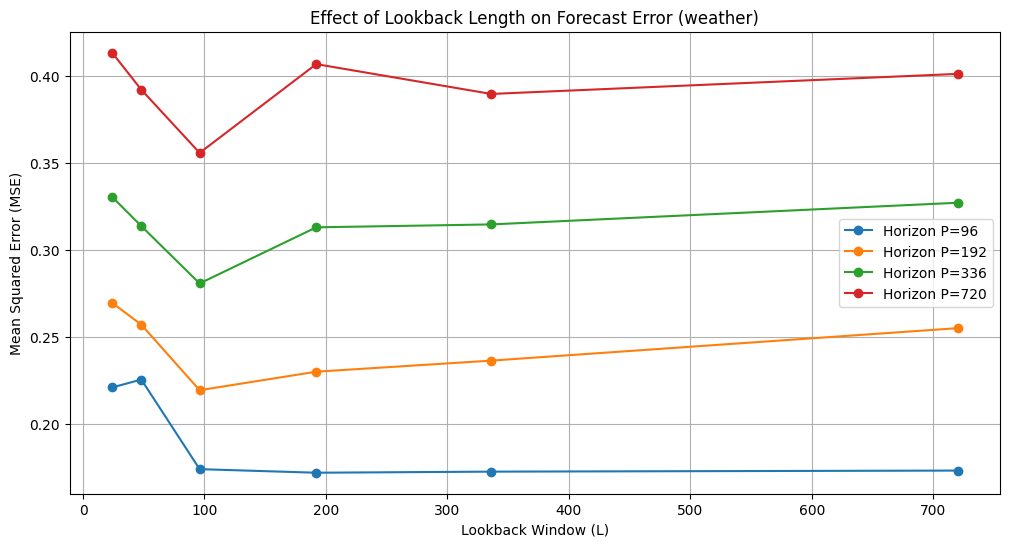

In [ ]:
df_results = pd.DataFrame(results_table)
df_results.to_csv(os.path.join(PROJECT_PATH, f"results_{dataset_name}.csv"), index=False)

plt.figure(figsize=(12, 6))
for P in P_windows:
    subset = df_results[df_results['Predict'] == P]
    plt.plot(subset['Lookback'], subset['MSE'], marker='o', label=f'Horizon P={P}')

plt.xlabel('Lookback Window (L)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'Effect of Lookback Length on Forecast Error ({dataset_name})')
plt.legend()
plt.grid(True)
plt.show()